In [3]:
# https://grouplens.org/datasets/movielens/100k/
# https://www.kaggle.com/code/thehoang56738/contentbase-filtering

import numpy as np
import pandas as pd

In [4]:
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']

# u.data instead of ua.base for alla datapoints.
data = pd.read_csv('ml-100k/u.data', sep='\t', names=r_cols, encoding='latin-1')
data.drop('unix_timestamp', inplace=True, axis=1)

<Axes: >

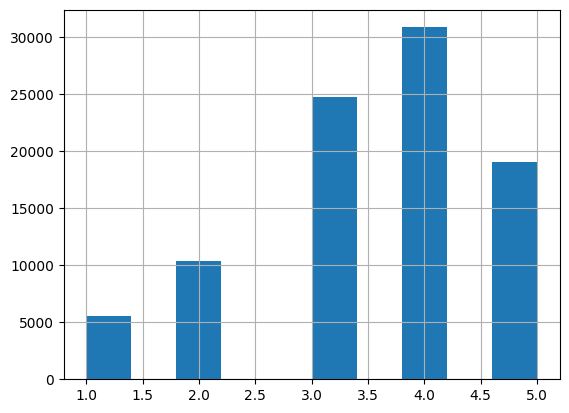

In [36]:
data['rating'].hist()

In [19]:
data.head()

,user_id,movie_id,rating
0,1,1,5
1,1,2,3
2,1,3,4
3,1,4,3
4,1,5,3


In [37]:
print('   len:', len(data))
print(' #user:', len(np.unique(data['user_id'])))
print('#movie:', len(np.unique(data['movie_id'])))
print('rating:', np.unique(data['rating']))

   len: 90570
 #user: 943
#movie: 1680
rating: [1 2 3 4 5]


In [ ]:
# Dataset which containts movie ratigns from 1 to 5. We keep only positive ratings, defined to be ratings of 3 or more ( we subtract 2 from all ratings and set the negative ones to 0).
# The context of each rating is the other movies rated by the same user. After removing users who rated fewer than 20 movies and movies that were rated fewer than 50 times.
# We end up with 777 users, and 516 moveis; 5% sparsity.

In [6]:
data['rating'] = data['rating'] - 2
data.loc[data['rating'] < 0, 'rating'] = 0
data.loc[data['rating'] > 0, 'rating'] = 1

movie_counts = data['movie_id'].value_counts()
movies_to_keep = movie_counts[movie_counts >= 50].index
user_counts = data['user_id'].value_counts()
users_to_keep = user_counts[user_counts >= 20].index

data = data[data['movie_id'].isin(movies_to_keep)]
data = data[data['user_id'].isin(users_to_keep)]



In [44]:
print('After filter')
print('   len:', len(data))
print(' #user:', len(np.unique(data['user_id'])))
print('#movie:', len(np.unique(data['movie_id'])))
print('rating:', np.unique(data['rating']))
print('rating:', np.sum(data['rating']==0))

After filter
   len: 83715
 #user: 943
#movie: 603
rating: [0 1]
rating: 12254


<Axes: >

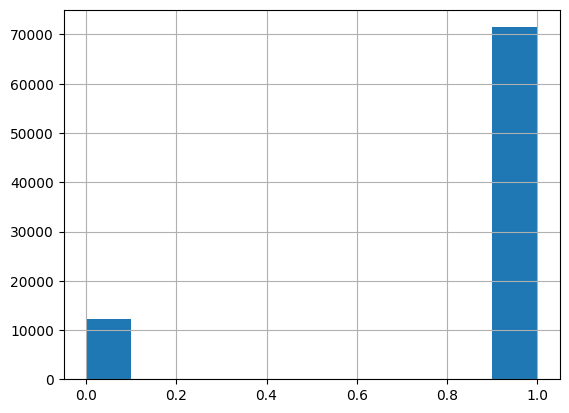

In [7]:
data['rating'].hist()

w is the center "word", in this case a movie_id and v the context movie. 'x' denotes if its a positive or negative word pair. The way we define x is as follows: If a movie has positive rating (1) and the context word is negative (0) we get x = 0,  if bot are 1 we set x = 1, if the center word is negative(0) we skip it.


In [22]:
data_sub = data.iloc[0:10000]

In [27]:
import pandas as pd
import json
import itertools
import numpy as np
from collections import Counter

def generate_word_pairs_with_negative_sampling(data, num_negative_samples=5):
    word_pairs = []
    
    # Filter out negatively rated movies -- TODO: is this reasonable?
    positive_data = data[data['rating'] == 1]
    
    # -- negative sampling: empirical distribution ** 3/4
    movie_counts = Counter(positive_data['movie_id'])
    total_count = sum(movie_counts.values())
    movie_distribution = {movie: (count/total_count)**0.75 for movie, count in movie_counts.items()}
    total_distribution = sum(movie_distribution.values())
    movie_distribution = {movie: freq/total_distribution for movie, freq in movie_distribution.items()}
    
    movies = list(movie_distribution.keys())
    probabilities = list(movie_distribution.values())
    
    for user_id in positive_data['user_id'].unique():
        user_movies = positive_data[positive_data['user_id'] == user_id]['movie_id'].tolist()
        
        # --- extract positive pairs ---
        for movie1, movie2 in itertools.combinations(user_movies, 2):
            word_pairs.append({
                "v": str(movie1),
                "w": str(movie2),
                "x": 1
            })
            word_pairs.append({
                "v": str(movie2),
                "w": str(movie1),
                "x": 1
            })
            
            # --- negative samples for each positive pair ---
            for _ in range(num_negative_samples):
                negative_movie = np.random.choice(movies, p=probabilities)
                while negative_movie in user_movies:
                    negative_movie = np.random.choice(movies, p=probabilities)
                
                word_pairs.append({
                    "v": str(movie1),
                    "w": str(negative_movie),
                    "x": 0
                })
                word_pairs.append({
                    "v": str(movie2),
                    "w": str(negative_movie),
                    "x": 0
                })
    
    return word_pairs


word_pairs = generate_word_pairs_with_negative_sampling(data_sub)

all_movies = set()
for pair in word_pairs:
    all_movies.add(pair['v'])
    all_movies.add(pair['w'])

vocabulary = {movie: idx for idx, movie in enumerate(sorted(all_movies))}

json_data = {
    "vocabulary": vocabulary,
    "data": word_pairs
}

with open('movielens_with_ns.json', 'w') as f:
    json.dump(json_data, f, indent=2)


In [13]:
25 * 84

2100

In [25]:
import sys
sys.getsizeof(json_data['data'])

17128280

In [20]:
len(json_data['data'])

97152

In [54]:
pd.DataFrame(json_data['data'])

,v,w,x
0,242,393,1
1,393,242,1
2,242,257,0
3,393,257,0
4,242,196,0
...,...,...,...
24883,333,461,0
24884,298,604,0
24885,333,604,0
24886,298,135,0
